In [1]:
import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils
from aeon.visualisation import plot_critical_difference
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()

/tmp/ipykernel_3999374/2919427637.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()


In [20]:
pl.Config.set_tbl_rows(100)

def model_counts(df: pl.LazyFrame) -> pl.DataFrame:
    return (
        df
        .group_by("model", "resampled")
        .agg(pl.len().alias("count"))
        .pivot(on="resampled", values="count", index="model")
        .sort("model")
    )

rdf.pipe(model_counts)

model,false,true
str,u32,u32
"""catch22""",640,640
"""cumsum-mr-hydra""",640,224
"""difference-mr-hydra""",640,610
"""downsample-mr-hydra""",640,608
"""drcif""",640,640
"""fast-stacker-v4-r1""",159,null
"""fast-stacker-v5-r1""",84,null
"""fast-stacker-v5-r3""",56,null
"""hivecotev2""",624,182


In [24]:
def filter_results(rdf, resampled: bool = False):
    excluded_models = [
        "stacker-v4-r3",
        "difference-mr-hydra",
        "scale-mr-hydra",
        "cumsum-mr-hydra",
        "downsample-mr-hydra",
        "rank-mr-hydra",
        "polar-magnitude-mr-hydra",
        "polar-angle-mr-hydra",
        "catch22",
        "fast-stacker-v4-r1",
        "fast-stacker-v5-r1",
        "fast-stacker-v5-r3",
        "quant-catboost",
        "stacker-v4-r1",

        "loky-stacker-v5-soft-ridge",
        "loky-stacker-v5-soft-rf",
        "mr-hydra-kbest-3000",
        "mr-hydra-kbest-30000",
        "mr-hydra-kbest-5000",
        "mr-hydra-kbest-1000",
        "mr-hydra-kbest-10000",

    ]
    
    return (
        rdf
        .filter(~pl.col("model").is_in(excluded_models))
        .filter(pl.col("resampled") == resampled)
    )

df = filter_results(rdf, resampled=False)
df.pipe(model_counts)

model,false
str,u32
"""drcif""",640
"""hivecotev2""",624
"""loky-stacker-v5-r1""",640
"""loky-stacker-v5-soft-et""",174
"""mr-hydra""",640
"""mr-hydra-baseline""",640
"""mr-hydra-sgd""",640
"""quant""",640
"""rdst""",640


In [25]:
def pivot(df):
    return df.pivot(
        on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
    ).drop_nulls()

101


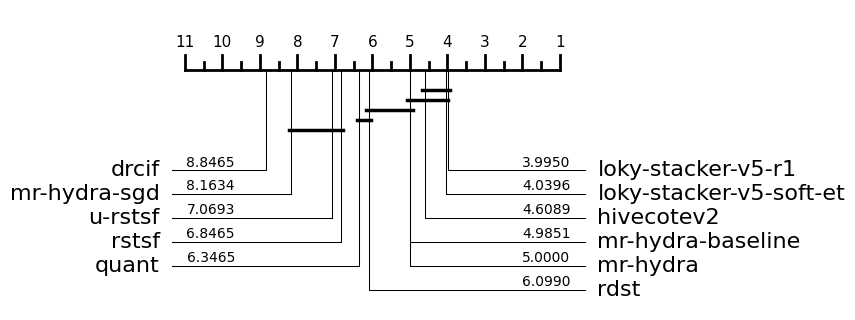

In [26]:
v = df.pipe(pivot)
methods = df["model"].unique().to_list()
plot_critical_difference(v.select(methods).to_numpy(), methods)
print(len(v))
directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

plt.savefig(f"{directory}/critical_difference_no_resampling.pdf", bbox_inches='tight', pad_inches=0)

In [27]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [28]:
joined = v.join(stats, on="dataset").sort("n_train")
#joined

54


(<Figure size 600x300 with 1 Axes>, <Axes: >)

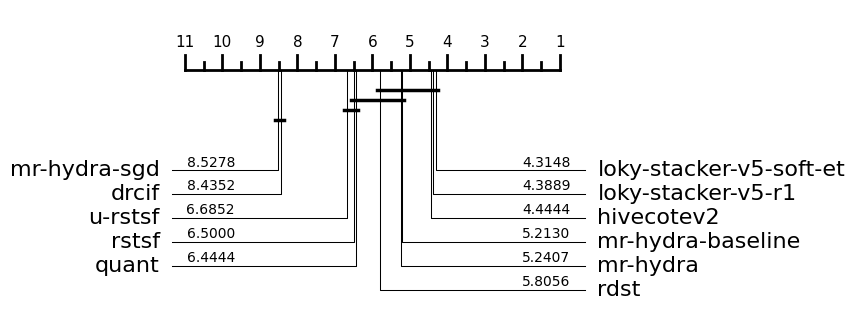

In [29]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

33


(<Figure size 600x300 with 1 Axes>, <Axes: >)

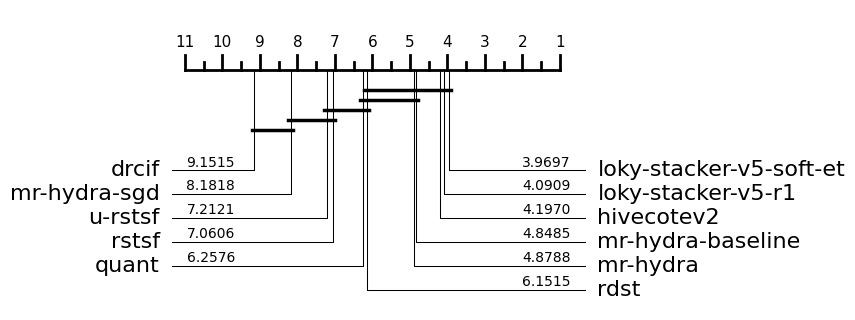

In [30]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

14


(<Figure size 600x300 with 1 Axes>, <Axes: >)

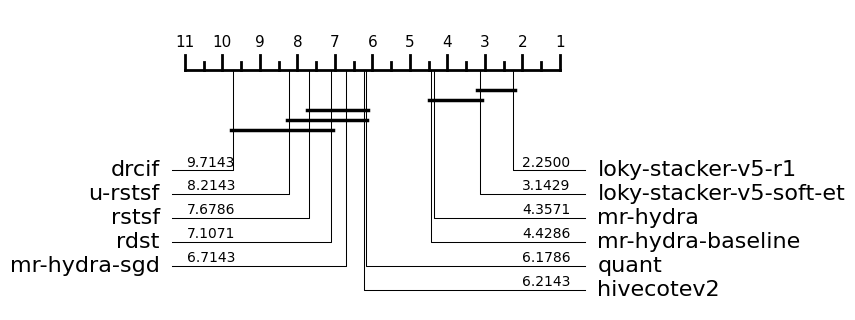

In [31]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [32]:
df = filter_results(rdf, resampled=True)
df.pipe(model_counts)

model,true
str,u32
"""drcif""",640
"""hivecotev2""",182
"""loky-stacker-v5-r1""",639
"""loky-stacker-v5-soft-et""",196
"""mr-hydra""",640
"""mr-hydra-baseline""",640
"""mr-hydra-sgd""",640
"""quant""",640
"""rdst""",640


83

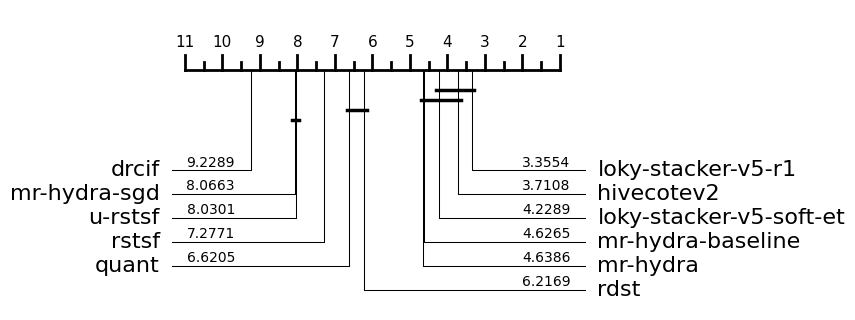

In [33]:
v = df.pipe(pivot)
methods = df["model"].unique().to_list()
plot_critical_difference(v.select(methods).to_numpy(), methods)
len(v)

In [34]:
joined = v.join(stats, on="dataset").sort("n_train")

38


(<Figure size 600x300 with 1 Axes>, <Axes: >)

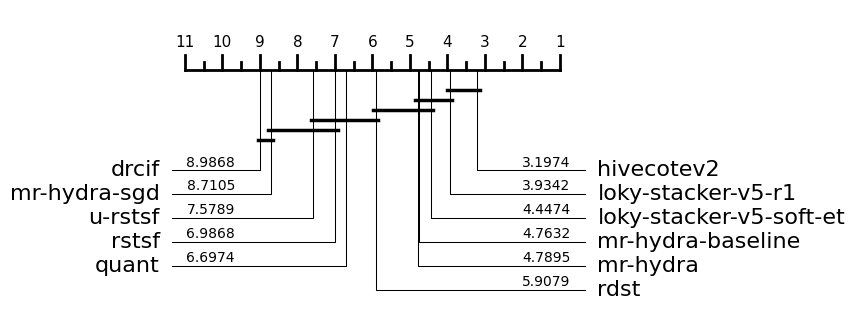

In [35]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

34


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators mr-hydra and mr-hydra-baseline have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(ordered_scores, ordered_labels, lower_better)


(<Figure size 600x300 with 1 Axes>, <Axes: >)

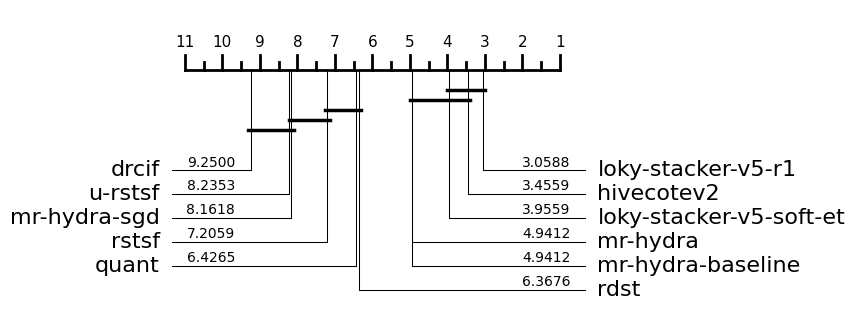

In [36]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

11


(<Figure size 600x300 with 1 Axes>, <Axes: >)

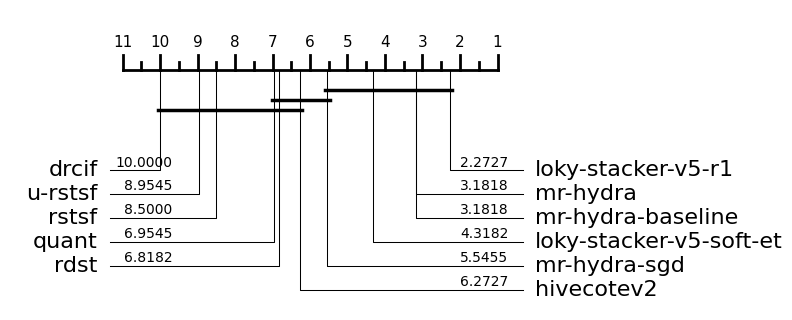

In [37]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

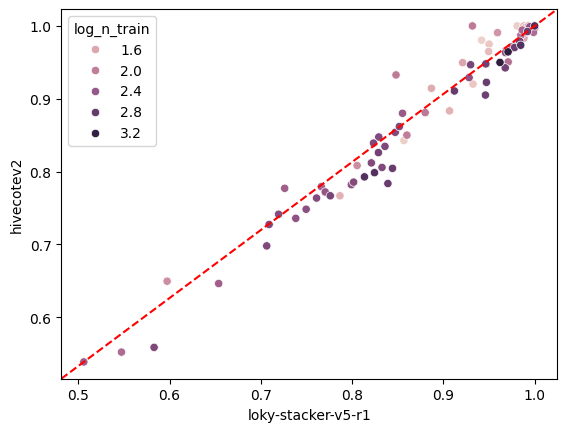

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = joined.to_pandas()
plot_df["log_n_train"] = np.log10(plot_df["n_train"])

sns.scatterplot(data=plot_df, x='loky-stacker-v5-r1', y='hivecotev2', hue='log_n_train')
plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes, color='red', linestyle='--')

In [39]:
v

dataset,drcif,loky-stacker-v5-r1,u-rstsf,mr-hydra-baseline,rdst,rstsf,quant,mr-hydra-sgd,mr-hydra,hivecotev2,loky-stacker-v5-soft-et
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Worms""",0.706494,0.766234,0.714286,0.727273,0.711688,0.737662,0.711688,0.683117,0.727273,0.779221,0.727273
"""AllGestureWiimoteZ""",0.588857,0.738286,0.651714,0.739143,0.685429,0.661143,0.675714,0.685429,0.739143,0.735714,0.752857
"""SmoothSubspace""",0.986667,0.998667,0.978667,0.986667,1.0,0.976,0.989333,0.972,0.986667,0.991111,1.0
"""Earthquakes""",0.741007,0.74964,0.748201,0.730935,0.728058,0.751079,0.76259,0.564029,0.730935,0.748201,0.738609
"""MoteStrain""",0.899361,0.932428,0.935144,0.909904,0.931949,0.936102,0.939936,0.876677,0.909904,0.920128,0.934505
"""Adiac""",0.778517,0.832737,0.796419,0.82711,0.744757,0.805115,0.819437,0.773402,0.82711,0.805627,0.820972
"""Lightning7""",0.728767,0.805479,0.742466,0.805479,0.761644,0.783562,0.745205,0.778082,0.805479,0.808219,0.808219
"""Mallat""",0.963667,0.978678,0.966482,0.955309,0.956674,0.96887,0.967591,0.956759,0.955309,0.973987,0.988273
"""GesturePebbleZ2""",0.93038,0.98481,0.93038,0.973418,0.983544,0.94557,0.960759,0.960759,0.973418,0.987342,0.974684
